In [47]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os
from pylab import *
mpl.rcParams['font.sans-serif'] = ['SimHei']

In [48]:
# 小盘：2.5-20 亿$
# 中盘：20-100 亿$
# 蓝筹：>100 亿$
# ---------------------------
# 1) 股票分组
# ---------------------------
AI_max = ["MSFT", "GOOGL", "META", "AMZN", "TSLA", "ORCL", "CRM", "ADBE"]
AI_mid = ["SNOW", "PLTR", "DDOG", "MDB", "U", "CRWD", "ZS", "NET"]
AI_min = ["AI", "BBAI", "SOUN", "VERI", "UPST", "CXAI"]

finance_max = ["JPM", "BAC", "WFC", "C", "GS", "MS", "AXP", "BLK", "SCHW"]
finance_mid = ["USB", "PNC", "TFC", "COF", "STT", "BK", "MTB", "FITB", "CFG"]
finance_min = ["HOOD", "SOFI", "AFRM", "LC", "MQ", "NU", "HIPO", "ROOT"]

encryption_max = ["COIN", "MSTR", "MARA", "RIOT", "CLSK", "HUT", "HIVE", "BITF"]
encryption_mid = ["CIFR", "WULF", "IREN", "BTBT", "CORZ", "BKKT", "BTDR"]
encryption_min = ["ANY", "ARBK", "ABTC", "GREE", "BTCS"]

semiconductor_max = ["NVDA", "AMD", "INTC", "AVGO", "QCOM", "TXN", "ADI", "MU", "NXPI", "TSM"]
semiconductor_mid = ["MCHP", "MPWR", "ON", "LRCX", "KLAC", "TER", "GFS"]
semiconductor_min = ["AEHR", "NVTS", "INDI", "LASR", "HIMX", "SMTC", "AMBA", "POWI"]

In [49]:
proxy = 'http://127.0.0.1:7890'  # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [4]:
# 彻底禁掉代理（见上一节）
for v in ("HTTP_PROXY", "HTTPS_PROXY", "http_proxy", "https_proxy"):
    os.environ.pop(v, None)

# 按照行业、盘子大小获取数据(每周)

In [5]:
# 展平去重
tickers = sorted(set(
    AI_max + AI_mid + AI_min +
    finance_max + finance_mid + finance_min +
    encryption_max + encryption_mid + encryption_min +
    semiconductor_max + semiconductor_mid + semiconductor_min
))

# ---------------------------
# 2) 下载日线（用 Adj Close 计算更稳）
#    然后转为周频并计算周涨跌幅
# ---------------------------
start_date = "2022-12-28"
end_date = "2025-12-29"  # end 是右开区间，写到 12-29 才能包含 12-28

data = yf.download(
    tickers=" ".join(tickers),
    start=start_date,
    end=end_date,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# 取 Adj Close（若没有则退回 Close）
if isinstance(data.columns, pd.MultiIndex):
    if ("Adj Close" in data.columns.get_level_values(1)):
        px = data.xs("Adj Close", axis=1, level=1)
    else:
        px = data.xs("Close", axis=1, level=1)
else:
    # 单只股票退化情况
    col = "Adj Close" if "Adj Close" in data.columns else "Close"
    px = data[[col]].rename(columns={col: tickers[0]})

# 周频：用每周最后一个交易日的收盘（周末对齐）
px_w = px.resample("W-FRI").last()

# 周涨跌幅：pct_change
df_stock_weekly = px_w.pct_change()

# 限定日期范围（保险）
df_stock_weekly = df_stock_weekly.loc["2022-12-28":"2025-12-28"]

In [6]:
df_stock_weekly

Ticker,NET,BKKT,AEHR,GS,BTCS,MU,PLTR,AXP,MS,INDI,...,KLAC,NU,SOFI,TER,ROOT,AMBA,NVTS,POWI,AVGO,ARBK
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-06,-0.117452,0.117647,0.134826,0.013687,0.357143,0.135854,-0.003115,0.019902,0.029875,0.058319,...,0.054531,-0.125307,0.002169,0.044533,-0.020044,0.010823,0.088319,0.055773,0.052403,0.314815
2023-01-13,0.101002,0.541353,0.281894,0.074466,0.883041,0.002818,0.087500,0.037225,0.046825,0.149109,...,0.056465,0.033708,0.177489,0.067953,0.202273,0.051371,0.198953,0.085182,-0.016026,0.035211
2023-01-20,0.038015,-0.024390,0.090971,-0.085989,-0.043478,0.026875,0.008621,-0.026708,0.049967,0.015515,...,-0.014737,0.035326,0.042279,0.000923,-0.035917,-0.015562,-0.039301,0.030181,-0.014197,0.176871
2023-01-27,0.164693,-0.135000,0.107837,0.034695,0.051948,0.092542,0.075499,0.136610,0.006442,0.093056,...,-0.034989,0.146982,0.047619,0.060597,0.100000,0.042660,0.175000,0.032132,0.035408,0.098266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-28,0.074203,0.128848,0.133202,0.067194,0.143885,0.140377,0.087827,0.035082,0.072643,0.082067,...,0.071414,0.094399,0.179833,0.145475,0.070823,-0.138844,0.156085,0.022701,0.184480,0.036036
2025-12-05,0.003696,-0.112238,0.077057,0.039655,0.047170,0.003129,0.079015,0.013908,0.040375,0.297753,...,0.033170,-0.039678,-0.065276,0.103799,-0.010384,-0.001078,0.084668,0.086607,-0.031566,-0.217391
2025-12-12,0.007415,-0.174286,-0.010509,0.039084,-0.030030,0.016525,0.009958,0.032969,0.010764,-0.071429,...,-0.016913,0.011976,-0.017999,-0.036858,0.012117,0.015924,-0.093882,-0.001096,-0.077670,-0.823302


In [20]:
# 如需保存
df_stock_weekly.to_csv("../data/USAstock_industry&size.csv", encoding="utf-8-sig")

# 按照行业、盘子大小获取数据(每天)

In [17]:
start_date = "2025-11-15"
end_date_exclusive = "2025-12-01"  # end 右开：包含到 11/30（若有交易日）

data2 = yf.download(
    tickers=" ".join(tickers),
    start=start_date,
    end=end_date_exclusive,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# 先提取日收盘价（优先 Close；没有就用 Adj Close）
if isinstance(data2.columns, pd.MultiIndex):
    if "Close" in data2.columns.get_level_values(1):
        px_daily = data2.xs("Close", axis=1, level=1)
    else:
        px_daily = data2.xs("Adj Close", axis=1, level=1)
else:
    col = "Close" if "Close" in data2.columns else "Adj Close"
    px_daily = data2[[col]].rename(columns={col: tickers[0]})

# 再保险截一下范围（只保留 11/15~11/30）
px_daily = px_daily.loc["2025-11-15":"2025-11-30"]

# 计算“日收益率 / 日涨跌幅”（简单收益率）
df_stock_daily = px_daily.pct_change()

# 如果你不想要第一行 NaN，可以取消注释：
# df_stock_daily = df_stock_daily.dropna(how="all")


In [18]:
df_stock_daily

Ticker,BKKT,INDI,AEHR,PLTR,TFC,NET,MU,BTCS,AXP,MS,...,NVDA,BITF,TER,SOFI,NVTS,POWI,AMBA,AVGO,ARBK,ROOT
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-18,0.019655,-0.049724,-0.016442,-0.022891,0.009563,-0.028282,-0.055590,0.176471,-0.001729,0.002383,...,-0.028081,0.029963,-0.022217,-0.029586,0.006468,-0.014246,-0.011539,-0.006275,0.000000,-0.002614
2025-11-19,-0.008178,-0.002907,0.006079,-0.011415,0.006991,-0.001679,-0.011291,-0.070000,0.011683,0.015391,...,0.028452,-0.054545,0.027547,0.018293,-0.007712,-0.007540,0.052353,0.040881,-0.033058,-0.048486
2025-11-20,-0.130742,-0.034985,-0.023162,-0.058488,-0.005599,-0.024516,-0.108667,-0.028674,-0.002437,-0.022121,...,-0.031525,0.000000,-0.073293,-0.067740,-0.022021,-0.021209,-0.047118,-0.021444,-0.012820,-0.049305
2025-11-21,-0.053523,-0.006042,0.044845,-0.005747,0.024324,-0.026177,0.029796,0.025830,0.026440,-0.003340,...,-0.009743,-0.065385,0.019307,0.011240,0.001324,0.069211,0.033845,-0.019088,-0.038961,0.094307
2025-11-24,0.116679,0.033435,0.029600,0.047788,0.000440,0.040831,0.079857,0.136691,0.008615,0.029462,...,0.020517,0.148148,0.044428,0.087733,0.096561,0.004840,0.039819,0.110993,0.121622,0.063212
2025-11-25,-0.014744,0.020588,0.030187,0.008012,0.018022,0.018042,0.002679,-0.028481,0.018852,0.015968,...,-0.025911,-0.007168,0.010243,0.033942,-0.031363,0.008730,0.015630,0.018706,-0.084337,-0.017120
2025-11-26,-0.031230,0.005764,0.064651,0.013574,-0.001727,-0.002532,0.025520,0.006515,0.003668,0.015173,...,0.013722,0.119134,0.069840,0.005648,0.038605,0.006565,-0.187754,0.032569,0.065789,0.032430
2025-11-28,0.059100,0.020057,0.003495,0.016167,0.005623,0.016346,0.027013,0.029126,0.003572,0.010242,...,-0.018085,0.122581,0.013993,0.043173,0.047962,-0.003854,0.003925,0.013557,-0.053498,-0.007485


# 按照行业、盘子大小获取数据(每分)

In [52]:
# 2025-11-20 当天：5分钟K线（end 右开，所以写到 11/21）
start_date = "2025-11-20"
end_date_exclusive = "2025-11-21"

data2 = yf.download(
    tickers=" ".join(tickers),
    start=start_date,
    end=end_date_exclusive,
    interval="5m",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# 提取 5分钟收盘价（优先 Close；没有就用 Adj Close）
if isinstance(data2.columns, pd.MultiIndex):
    if "Close" in data2.columns.get_level_values(1):
        px_5m = data2.xs("Close", axis=1, level=1)
    else:
        px_5m = data2.xs("Adj Close", axis=1, level=1)
else:
    col = "Close" if "Close" in data2.columns else "Adj Close"
    px_5m = data2[[col]].rename(columns={col: tickers[0]})

# 只保留 2025-11-20 当天的bar（稳妥起见再切一下）
px_5m = px_5m.loc["2025-11-20":"2025-11-20 23:59:59"]

# 5分钟“涨跌幅/收益率”：相邻两个5分钟bar的简单收益率
df_stock_minute = px_5m.pct_change()


1 Failed download:
['BAC']: Timeout('Failed to perform, curl: (28) Connection timed out after 10005 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\3944924212.py:30: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_stock_minute = px_5m.pct_change()


In [53]:
df_stock_minute

Ticker,INDI,TFC,AEHR,PLTR,BTCS,NET,QCOM,BKKT,MU,MS,...,TER,ROOT,SOFI,AVGO,POWI,NVTS,AMBA,SMTC,ARBK,BAC
2025-11-20 14:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-20 14:35:00+00:00,0.005587,-0.001536,-0.010293,0.003875,-0.009709,-0.011116,-0.003552,0.018182,-0.017738,0.001416,...,-0.004577,-0.014549,-0.002857,-0.000457,-0.004813,-0.004779,-0.008135,-0.006171,0.002808,NaN
2025-11-20 14:40:00+00:00,-0.002778,-0.000857,-0.002260,-0.008609,0.003268,-0.002723,-0.001280,-0.014509,-0.005982,0.000752,...,0.001717,0.011648,0.004477,-0.001626,-0.003744,-0.007203,-0.003318,0.000000,-0.010000,NaN
2025-11-20 14:45:00+00:00,-0.005571,0.002178,-0.013646,-0.002782,0.000000,-0.003081,0.003338,-0.010759,-0.014808,-0.002359,...,-0.008512,-0.015397,-0.009806,0.003957,0.004385,-0.005441,-0.001825,-0.002217,0.021818,NaN
2025-11-20 14:50:00+00:00,0.002801,-0.003731,0.000243,0.004446,0.001433,0.006482,-0.002376,-0.004579,0.009975,-0.001431,...,0.004014,-0.009655,0.003475,0.008613,-0.005613,0.026140,-0.003878,-0.000963,-0.011467,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-20 20:35:00+00:00,-0.007489,-0.001345,-0.006821,-0.007611,-0.007080,-0.007043,-0.001993,-0.009324,-0.006115,-0.001475,...,-0.001156,-0.004189,-0.003004,-0.001453,0.000323,-0.005007,-0.000298,-0.002695,-0.029787,NaN
2025-11-20 20:40:00+00:00,-0.000030,-0.001347,-0.002050,-0.002792,-0.007558,-0.003618,-0.002340,-0.004034,0.002410,-0.001163,...,-0.000836,0.003771,-0.006107,-0.003442,-0.003064,0.001093,-0.001849,-0.001828,0.005702,NaN
2025-11-20 20:45:00+00:00,0.000000,-0.002585,-0.000514,-0.005052,-0.003161,0.000605,-0.000751,-0.007249,-0.004141,-0.002140,...,-0.003089,-0.002095,-0.005080,-0.002154,0.001132,0.001960,-0.004243,-0.000478,0.005233,NaN
2025-11-20 20:50:00+00:00,0.006061,0.001239,0.000000,0.006048,-0.005405,0.006706,-0.003506,0.002203,0.006008,0.002082,...,0.000194,0.008544,0.001211,0.001753,-0.001131,-0.004596,0.009363,-0.003744,-0.015184,NaN


# 按照行业获取ETF涨跌幅数据（每周）

In [13]:
# ---------------------------
AI_ETF = ["QQQ", "AIQ", "BOTZ"]
FIN_ETF = ["XLF", "KRE", "PSCF"]
CRYP_ETF = ["IBIT", "BLOK", "WGMI"]
SEMI_ETF = ["SMH", "SOXX", "XSD"]

etfs = sorted(set(AI_ETF + FIN_ETF + CRYP_ETF + SEMI_ETF))

In [31]:
# ---------------------------
# 2. 时间区间
# ---------------------------
start_date = "2022-12-28"
end_date = "2025-12-29"   # 右开区间，确保包含 12-28

# ---------------------------
# 3. 下载日线数据
# ---------------------------
data = yf.download(
    tickers=" ".join(etfs),
    start=start_date,
    end=end_date,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# ---------------------------
# 4. 提取收盘价（优先 Adj Close）
# ---------------------------
if isinstance(data.columns, pd.MultiIndex):
    if "Adj Close" in data.columns.get_level_values(1):
        prices = data.xs("Adj Close", axis=1, level=1)
    else:
        prices = data.xs("Close", axis=1, level=1)
else:
    # 单 ETF 的退化情况
    col = "Adj Close" if "Adj Close" in data.columns else "Close"
    prices = data[[col]].rename(columns={col: etfs[0]})

# ---------------------------
# 5. 转周频 & 计算周涨跌幅
# ---------------------------
prices_weekly = prices.resample("W-FRI").last()
df_etf_weekly = prices_weekly.pct_change()

# 截取指定区间
df_etf_weekly = df_etf_weekly.loc["2022-12-28":"2025-12-28"]

In [32]:
df_etf_weekly

Ticker,IBIT,AIQ,WGMI,XLF,QQQ,BOTZ,KRE,PSCF,XSD,SMH,SOXX,BLOK
Date,,,,,,,,,,,,
2022-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-06,NaN,0.034328,0.165548,0.034503,0.009463,0.033577,0.016343,0.017037,0.033666,0.043018,0.045089,0.038360
2023-01-13,NaN,0.062530,0.495201,0.020916,0.045275,0.058851,0.015243,0.037794,0.073528,0.066708,0.061979,0.133121
2023-01-20,NaN,0.007062,0.064185,-0.021318,0.006086,0.016897,-0.013859,-0.016732,0.002209,0.006909,-0.001761,0.036537
2023-01-27,NaN,0.041985,0.107358,0.025459,0.048040,0.039353,0.019575,0.013613,0.062480,0.052474,0.055949,0.029284
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-28,0.074630,0.053361,0.273134,0.032127,0.049452,0.050164,0.022399,0.022776,0.087776,0.080183,0.095669,0.126756
2025-12-05,-0.016683,0.026725,-0.059880,0.006563,0.010061,0.045493,0.027465,0.003507,0.064169,0.034461,0.042664,-0.012145
2025-12-12,0.010061,-0.018648,-0.061278,0.023659,-0.018961,-0.010606,0.036465,0.027957,-0.040443,-0.028264,-0.032062,-0.012132


# 按照行业获取ETF涨跌幅数据（每日）

In [27]:
# ---------------------------
# 2. 时间区间（end 右开：要包含 2025-12-01，就写到 2025-12-02）
# ---------------------------
start_date = "2025-11-15"
end_date   = "2025-12-02"

# ---------------------------
# 3. 下载日线数据
# ---------------------------
data = yf.download(
    tickers=" ".join(etfs),
    start=start_date,
    end=end_date,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# ---------------------------
# 4. 提取日价格（Close；若没有 Close 就退回 Adj Close）
# ---------------------------
if isinstance(data.columns, pd.MultiIndex):
    if "Close" in data.columns.get_level_values(1):
        px_daily = data.xs("Close", axis=1, level=1)
    else:
        px_daily = data.xs("Adj Close", axis=1, level=1)
else:
    col = "Close" if "Close" in data.columns else "Adj Close"
    px_daily = data[[col]].rename(columns={col: etfs[0]})

# ---------------------------
# 5. 截取区间：2025-11-15 ~ 2025-12-01（两端都包含）
# ---------------------------
px_daily = px_daily.loc["2025-11-15":"2025-12-01"]

# ---------------------------
# 6. 计算“日收益率 / 日涨跌幅”
# ---------------------------
df_etf_daily = px_daily.pct_change()
# 如果不想要第一行 NaN，可取消注释：
# df_etf_daily = df_etf_daily.dropna(how="all")

In [28]:
df_etf_daily

Ticker,AIQ,SOXX,IBIT,XSD,BOTZ,KRE,BLOK,QQQ,PSCF,SMH,WGMI,XLF
Date,,,,,,,,,,,,
2025-11-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-18,-0.014141,-0.023205,0.010749,-0.016490,-0.018065,0.009040,0.003438,-0.012176,0.006814,-0.020599,0.022239,-0.001555
2025-11-19,-0.000205,0.016716,-0.036650,0.010593,0.004154,0.010649,-0.014902,0.005970,-0.000366,0.018452,-0.034186,0.003699
2025-11-20,-0.029924,-0.047974,-0.034891,-0.039123,-0.022459,-0.003345,-0.035646,-0.023672,-0.006404,-0.042246,-0.040594,-0.008728
2025-11-21,0.005705,0.010183,-0.020221,0.026264,0.012394,0.033898,0.001443,0.007513,0.026888,0.003168,-0.018576,0.010957
2025-11-24,0.031723,0.043828,0.054201,0.043465,0.017319,0.000812,0.051854,0.025573,0.001076,0.039831,0.133544,0.004258
2025-11-25,0.002851,0.003113,-0.019972,0.007461,0.014089,0.028381,0.007874,0.006164,0.023827,0.002624,0.012291,0.012527
2025-11-26,0.008528,0.027541,0.029661,0.017067,0.009262,-0.003785,0.038553,0.008836,0.000175,0.022646,0.056586,0.007804
2025-11-28,0.009462,0.018360,0.010190,0.017382,0.008603,-0.002849,0.023385,0.008107,-0.002274,0.013143,0.050087,0.007177


# 以周为单位，计算每个小类涨跌幅均值，与行业ETF涨跌幅比较,进行可视化

In [54]:
# 个股分组
groups = {
    "AI": {
        "max": AI_max,
        "mid": AI_mid,
        "min": AI_min,
        "etf": ["QQQ", "AIQ", "BOTZ"]
    },
    "Finance": {
        "max": finance_max,
        "mid": finance_mid,
        "min": finance_min,
        "etf": ["XLF", "KRE", "PSCF"]
    },
    "Crypto": {
        "max": encryption_max,
        "mid": encryption_mid,
        "min": encryption_min,
        "etf": ["IBIT", "BLOK", "WGMI"]
    },
    "Semiconductor": {
        "max": semiconductor_max,
        "mid": semiconductor_mid,
        "min": semiconductor_min,
        "etf": ["SMH", "SOXX", "XSD"]
    }
}

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


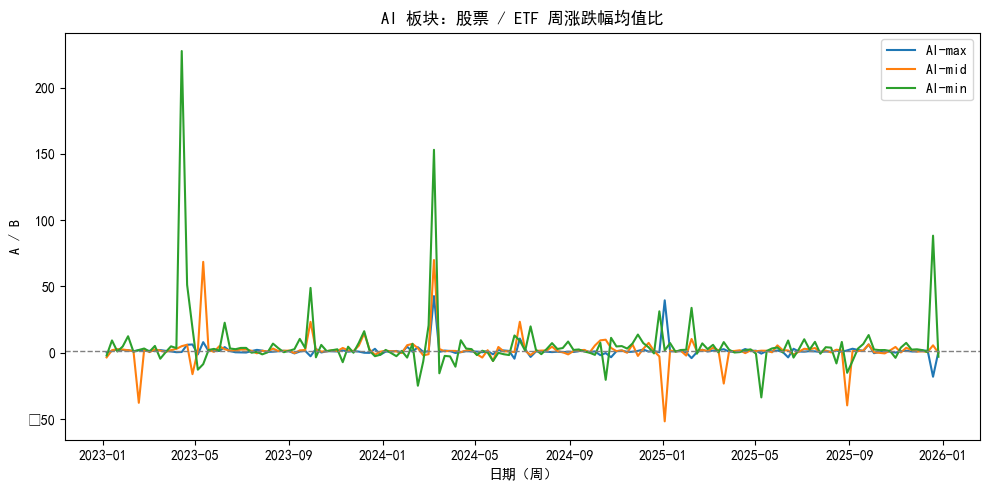

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


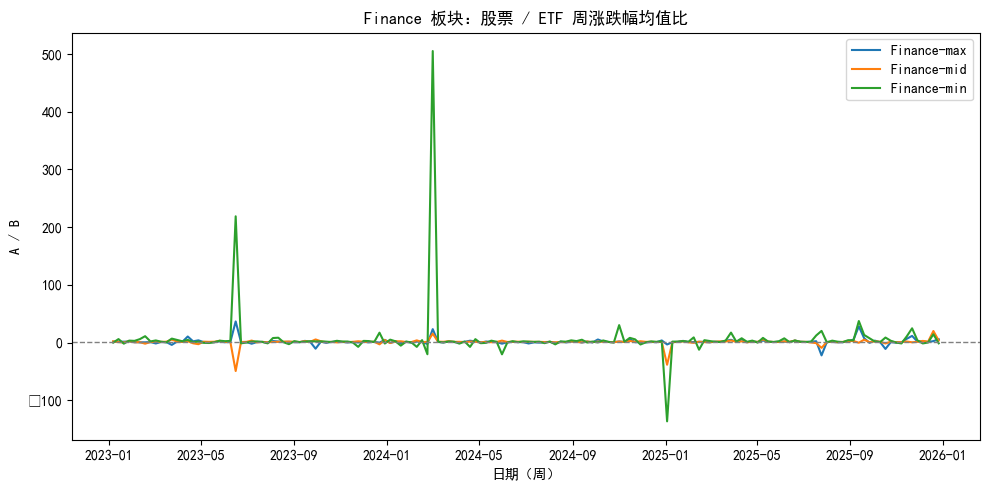

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


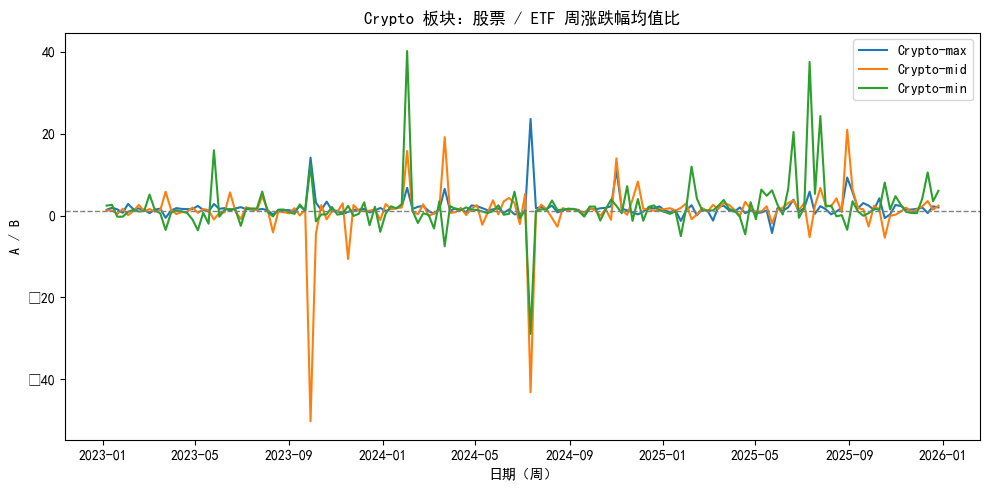

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


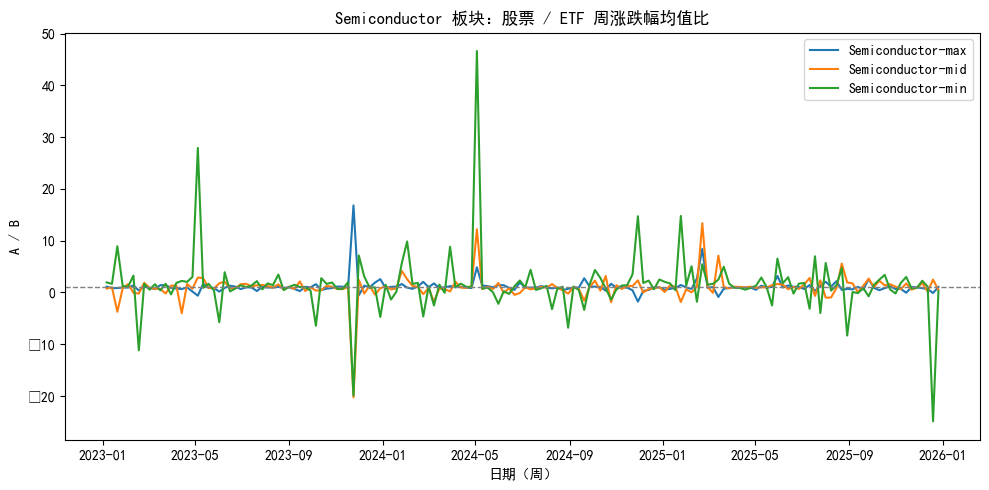

In [55]:
# =========================
# 主循环：每个行业一张图
# =========================
for sector, cfg in groups.items():

    fig, ax = plt.subplots(figsize=(10, 5))

    # ---------
    # 行业 ETF 周涨跌幅均值 B
    # ---------
    etf_cols = [c for c in cfg["etf"] if c in df_etf_weekly.columns]
    if len(etf_cols) == 0:
        print(f"{sector}: ETF 数据缺失，跳过")
        continue

    B = df_etf_weekly[etf_cols].mean(axis=1)

    # ---------
    # 三个小类：max / mid / min
    # ---------
    for size, stock_list in zip(
        ["max", "mid", "min"],
        [cfg["max"], cfg["mid"], cfg["min"]]
    ):
        stock_cols = [c for c in stock_list if c in df_stock_weekly.columns]
        if len(stock_cols) == 0:
            print(f"{sector}-{size}: 无股票数据，跳过")
            continue

        # A：该小类股票周涨跌幅均值
        A = df_stock_weekly[stock_cols].mean(axis=1)

        # A / B
        ratio = A / B

        ax.plot(
            ratio.index,
            ratio,
            label=f"{sector}-{size}"
        )

    ax.axhline(1.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"{sector} 板块：股票 / ETF 周涨跌幅均值比")
    ax.set_ylabel("A / B")
    ax.set_xlabel("日期（周）")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 以日为单位，对每支股票涨跌幅可视化

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\3144586000.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


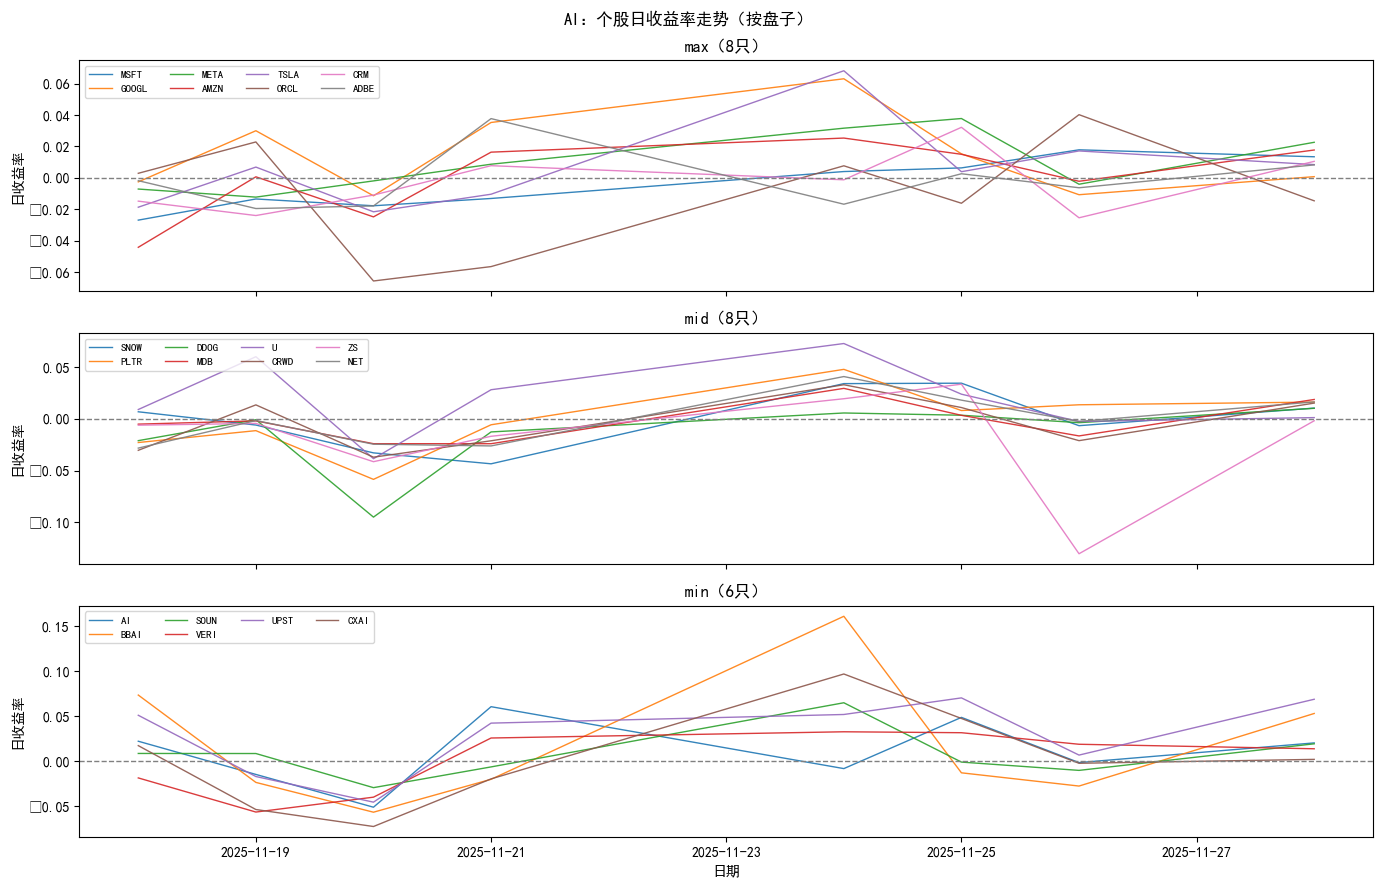

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\3144586000.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


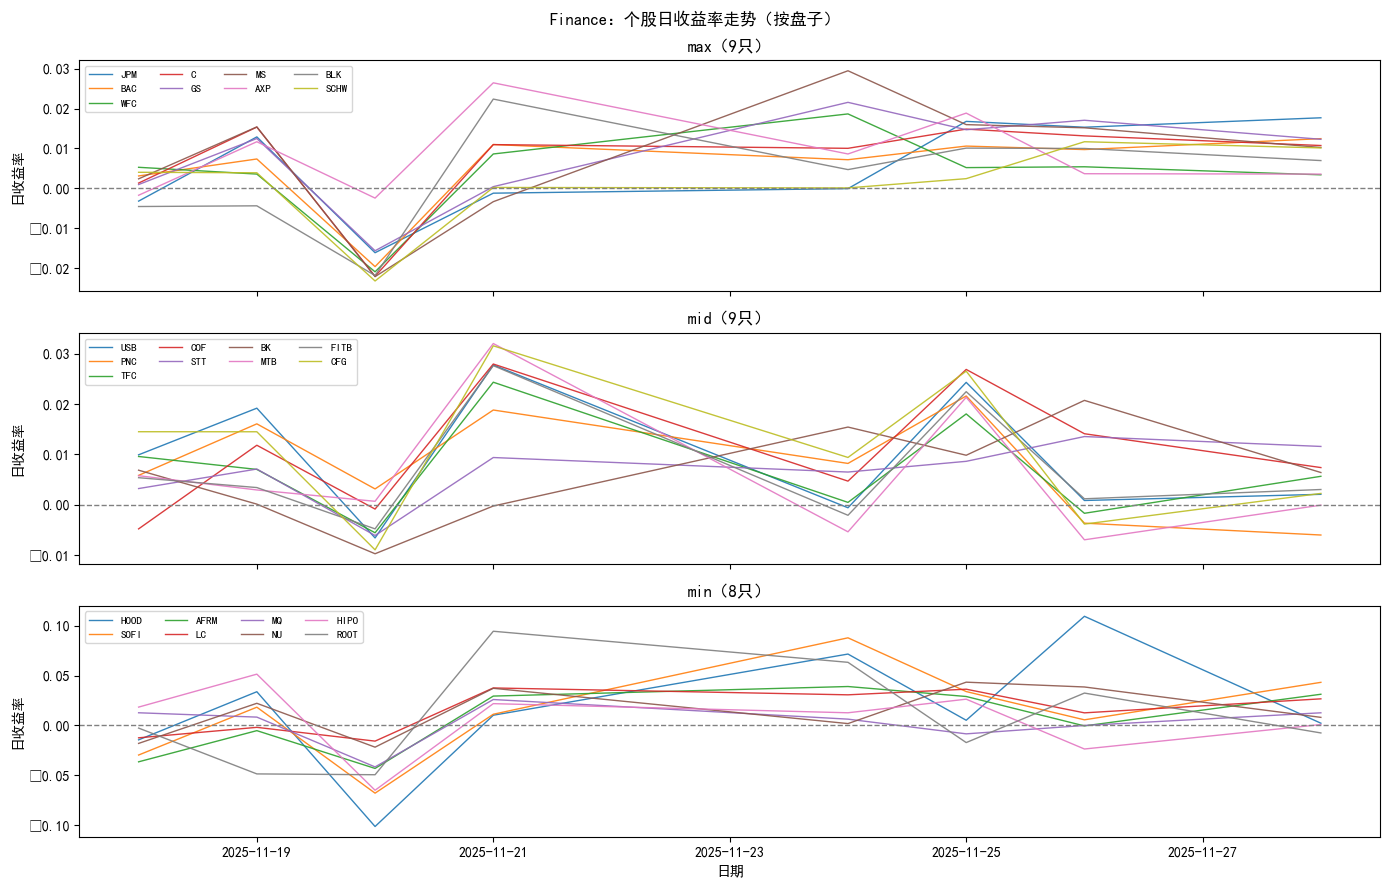

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\3144586000.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


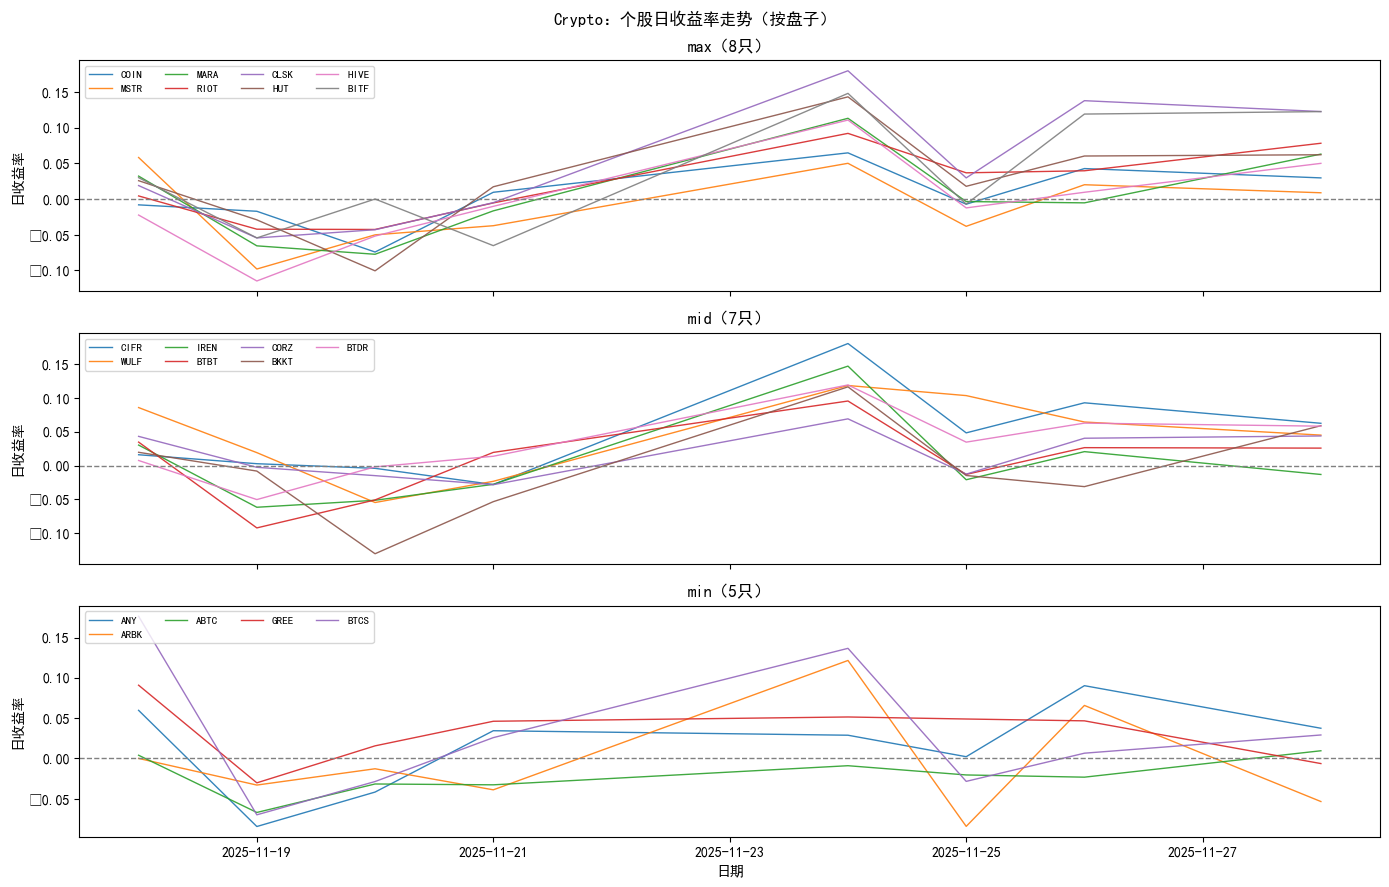

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\3144586000.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


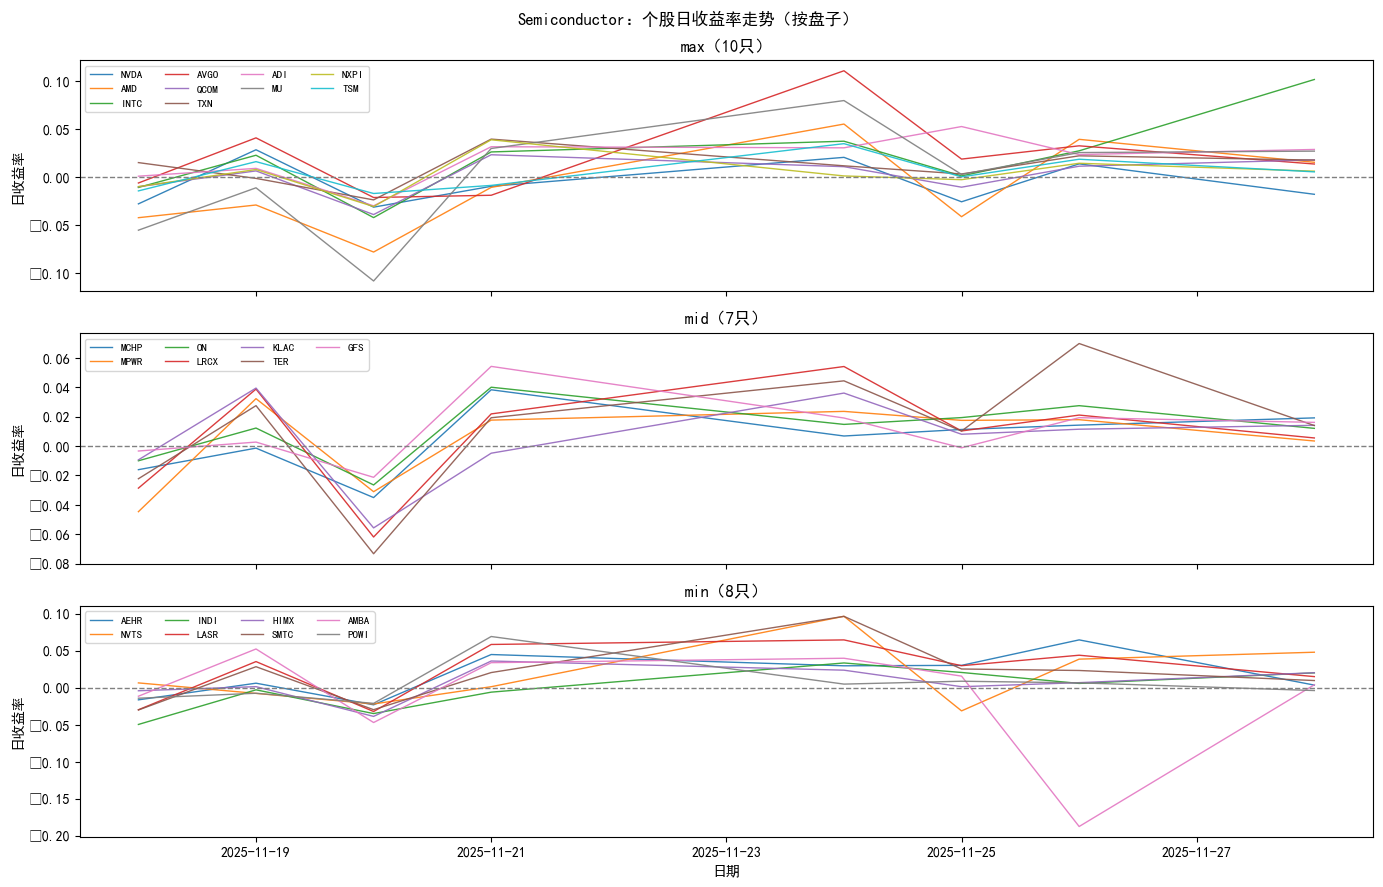

In [24]:
df = df_stock_daily.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# =========================
# 按行业 + 盘子：画每支股票“日收益率走势”
# 每个行业一张图，3 个子图分别是 max / mid / min
# =========================
for sector, cfg in groups.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"{sector}：个股日收益率走势（按盘子）", y=0.98)

    for ax, size, stock_list in zip(
        axes,
        ["max", "mid", "min"],
        [cfg["max"], cfg["mid"], cfg["min"]]
    ):
        stock_cols = [s for s in stock_list if s in df.columns]
        if len(stock_cols) == 0:
            ax.text(0.5, 0.5, f"{size}: 无股票数据", transform=ax.transAxes,
                    ha="center", va="center")
            ax.set_axis_off()
            continue

        sub = df[stock_cols].dropna(how="all")

        # 线很多时不画 legend（避免太乱）；线少时画 legend
        if len(stock_cols) <= 20:
            for t in stock_cols:
                ax.plot(sub.index, sub[t], linewidth=1, alpha=0.9, label=t)
            ax.legend(fontsize=8, ncol=4, loc="upper left")
        else:
            ax.plot(sub.index, sub.values, linewidth=0.8, alpha=0.7)
            ax.text(0.99, 0.01, f"{len(stock_cols)} stocks (legend omitted)",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

        ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
        ax.set_title(f"{size}（{len(stock_cols)}只）")
        ax.set_ylabel("日收益率")

    axes[-1].set_xlabel("日期")
    plt.tight_layout()
    plt.show()

# 以分为单位，对每支股票涨跌幅可视化

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\1160267586.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


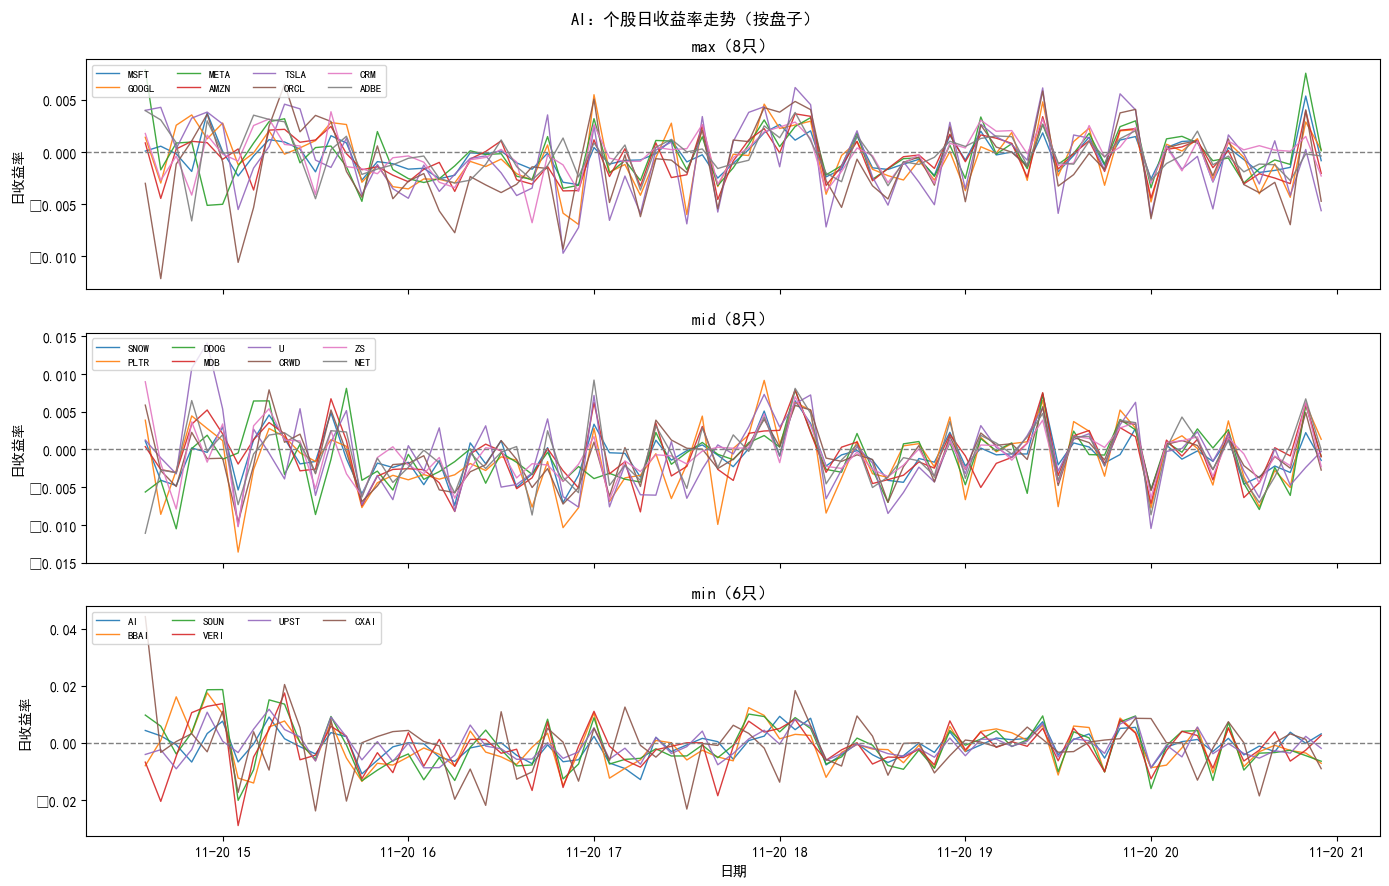

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\1160267586.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


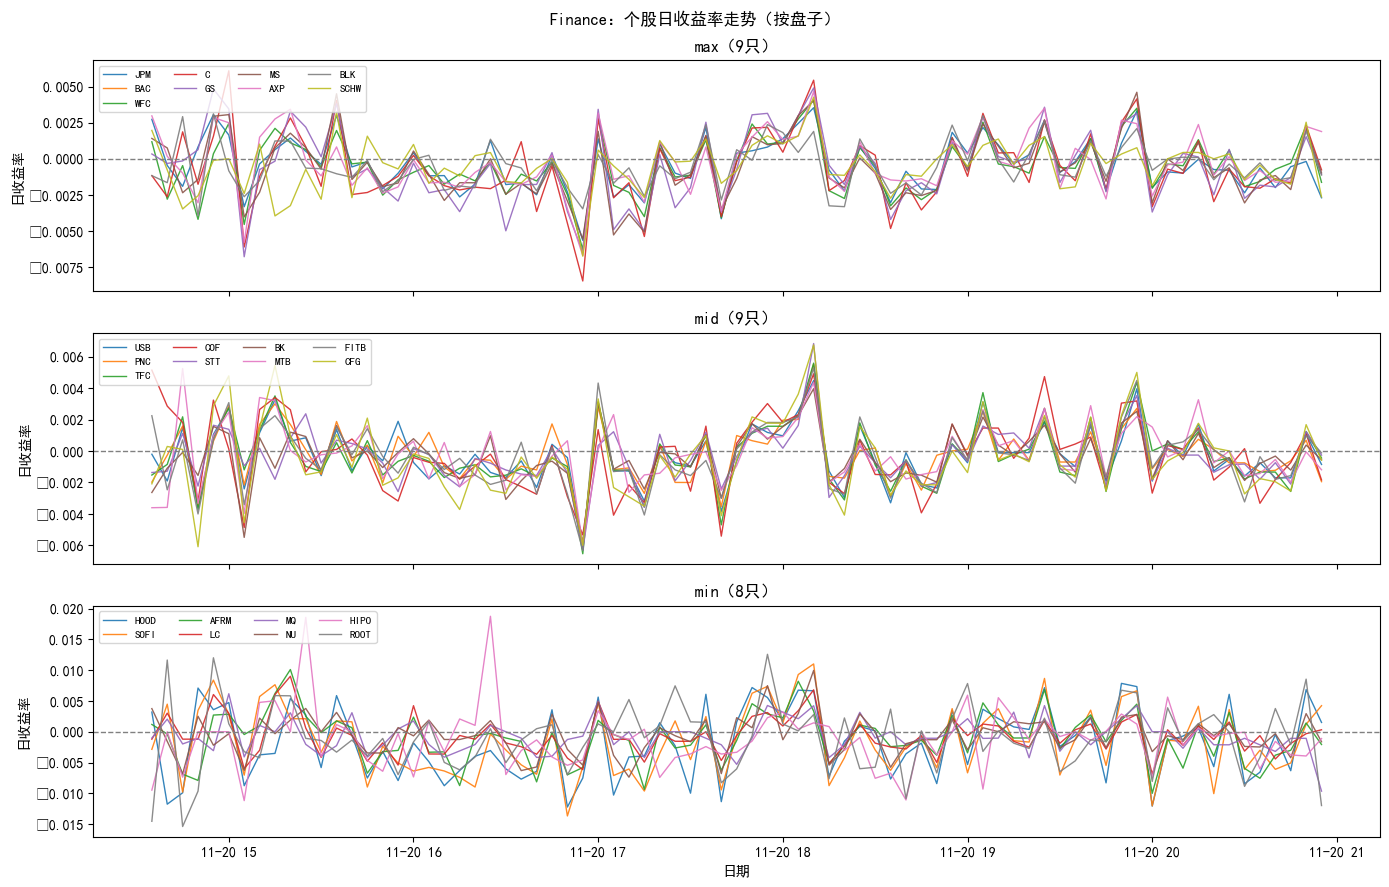

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\1160267586.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


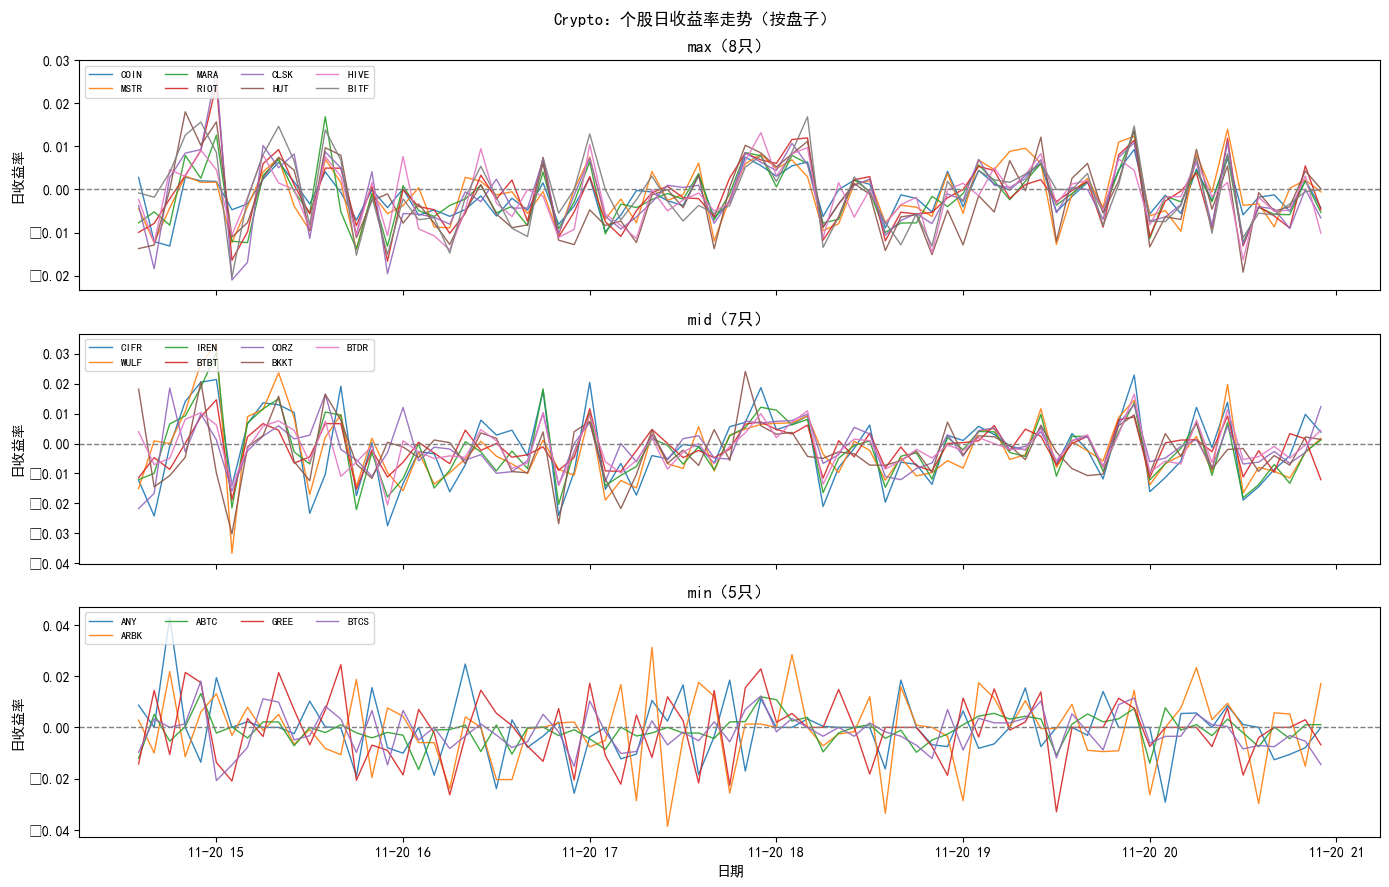

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\1160267586.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


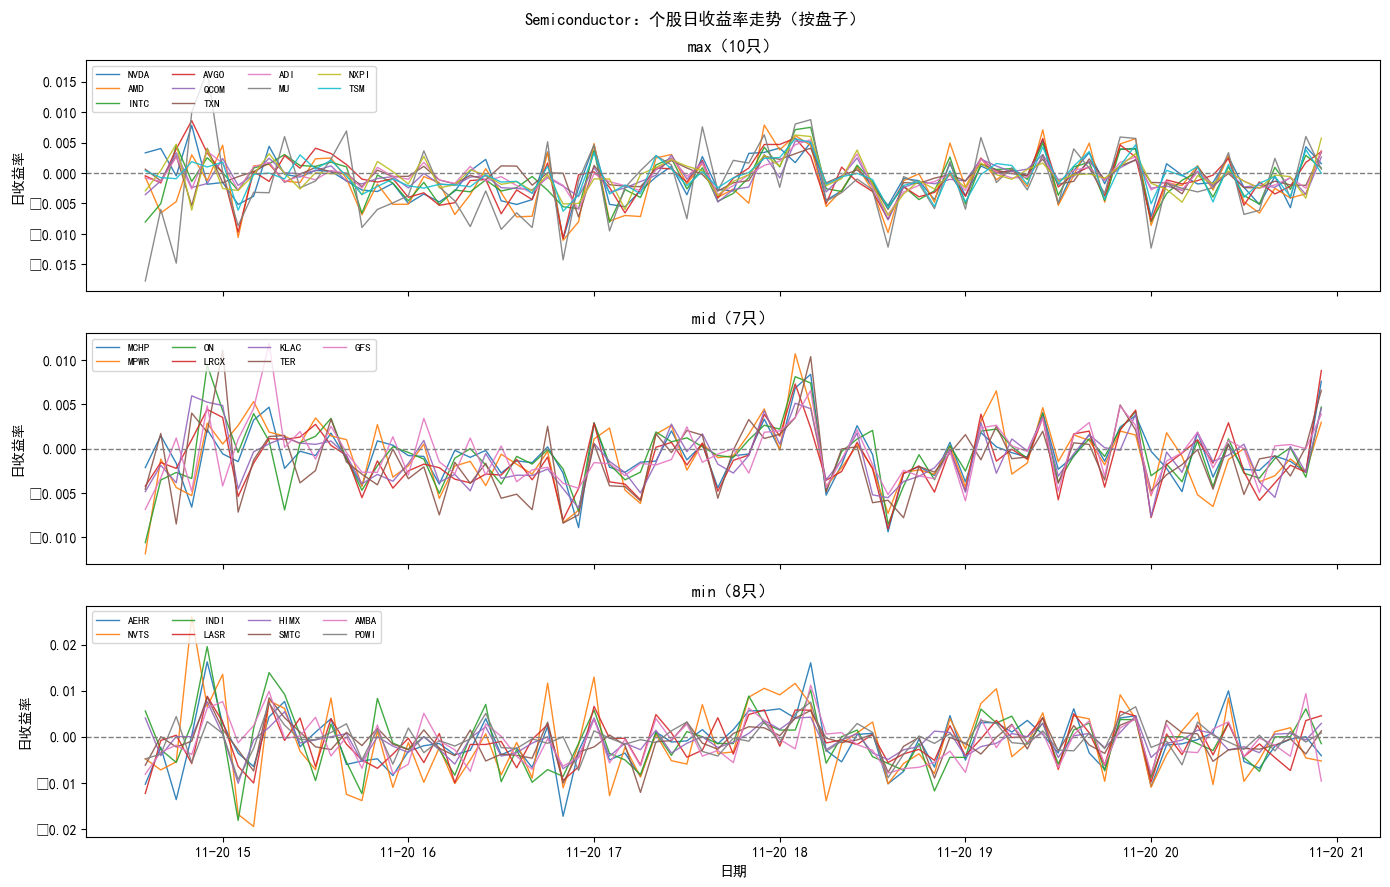

In [56]:
# 确保索引是日期
df = df_stock_minute.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# =========================
# 按行业 + 盘子：画每支股票“日收益率走势”
# 每个行业一张图，3 个子图分别是 max / mid / min
# =========================
for sector, cfg in groups.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"{sector}：个股日收益率走势（按盘子）", y=0.98)

    for ax, size, stock_list in zip(
        axes,
        ["max", "mid", "min"],
        [cfg["max"], cfg["mid"], cfg["min"]]
    ):
        stock_cols = [s for s in stock_list if s in df.columns]
        if len(stock_cols) == 0:
            ax.text(0.5, 0.5, f"{size}: 无股票数据", transform=ax.transAxes,
                    ha="center", va="center")
            ax.set_axis_off()
            continue

        sub = df[stock_cols].dropna(how="all")

        # 线很多时不画 legend（避免太乱）；线少时画 legend
        if len(stock_cols) <= 20:
            for t in stock_cols:
                ax.plot(sub.index, sub[t], linewidth=1, alpha=0.9, label=t)
            ax.legend(fontsize=8, ncol=4, loc="upper left")
        else:
            ax.plot(sub.index, sub.values, linewidth=0.8, alpha=0.7)
            ax.text(0.99, 0.01, f"{len(stock_cols)} stocks (legend omitted)",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

        ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
        ax.set_title(f"{size}（{len(stock_cols)}只）")
        ax.set_ylabel("日收益率")

    axes[-1].set_xlabel("日期")
    plt.tight_layout()
    plt.show()

# 以周为单位，计算每个小类涨跌幅均值，与行业ETF涨跌幅比较,进行可视化

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\3501921323.py:41: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


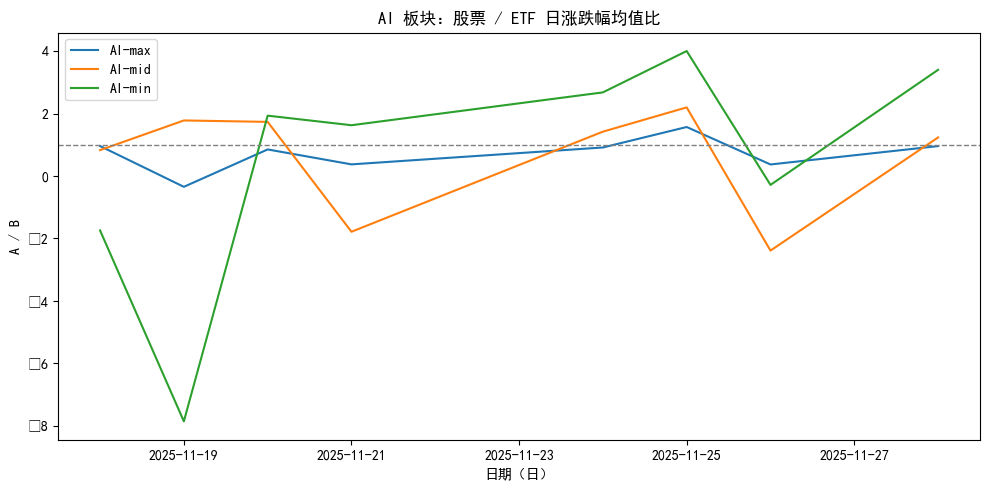

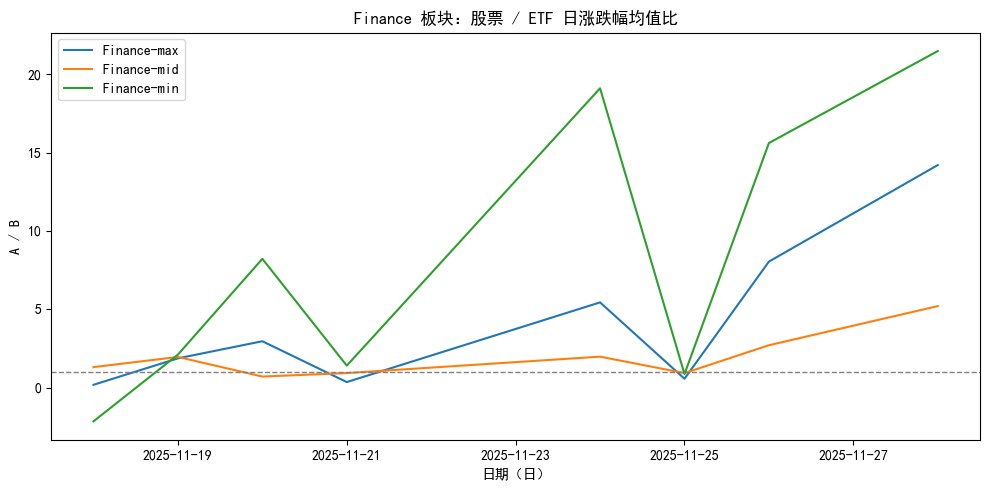

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16368\3501921323.py:41: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


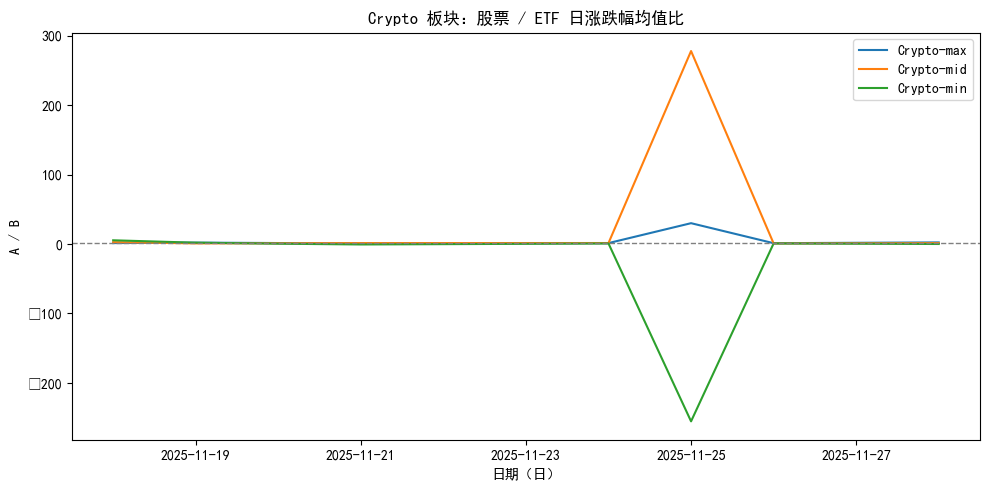

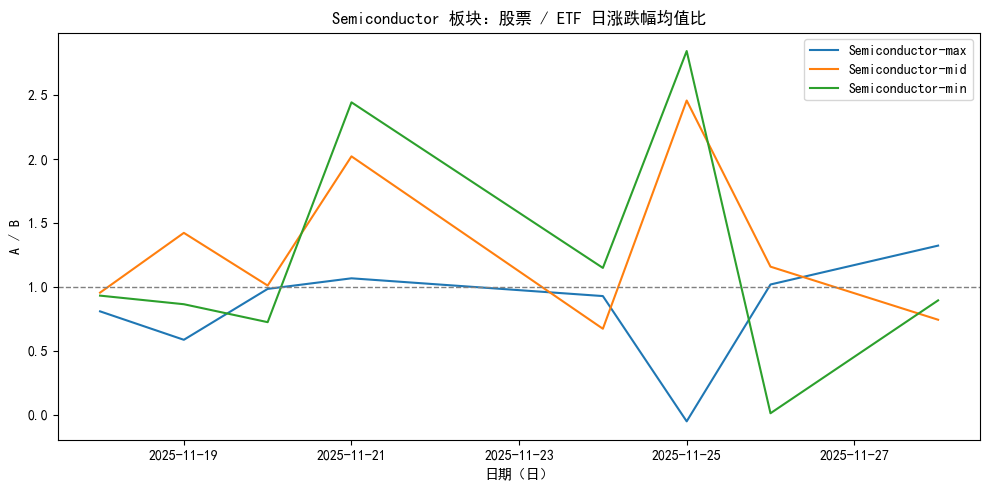

In [45]:
for sector, cfg in groups.items():

    fig, ax = plt.subplots(figsize=(10, 5))
    
    # ---------
    # 行业 ETF 日涨跌幅均值 B
    # ---------
    etf_cols = [c for c in cfg["etf"] if c in df_etf_daily.columns]
    if len(etf_cols) == 0:
        print(f"{sector}: ETF 数据缺失，跳过")
        plt.close(fig)
        continue

    B = df_etf_daily[etf_cols].mean(axis=1, skipna=True).replace(0, np.nan)

    # ---------
    # 三个小类：max / mid / min
    # ---------
    for size, stock_list in zip(
        ["max", "mid", "min"],
        [cfg["max"], cfg["mid"], cfg["min"]]
    ):
        stock_cols = [c for c in stock_list if c in df_stock_daily.columns]
        if len(stock_cols) == 0:
            print(f"{sector}-{size}: 无股票数据，跳过")
            continue

        # A：该小类股票 日涨跌幅均值
        A = df_stock_daily[stock_cols].mean(axis=1, skipna=True)

        # A / B（pandas 自动按日期对齐）
        ratio = (A / B).replace([np.inf, -np.inf], np.nan).dropna()

        ax.plot(ratio.index, ratio, label=f"{sector}-{size}")

    ax.axhline(1.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"{sector} 板块：股票 / ETF 日涨跌幅均值比")
    ax.set_ylabel("A / B")
    ax.set_xlabel("日期（日）")
    ax.legend()
    plt.tight_layout()
    plt.show()